In [3]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_plots import NeuronPlots
from neuron_utils import NeuronUtils
from neuron import h
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# LTP → Naturally occuring inputs (in electric field)

In the previous simulation, we performed LTP induction protocol and obtained synaptic weights. Here they are:

In [2]:
synapse_info = pd.read_csv("final_ef.csv", index_col = 0)
synapse_info

,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,14,0.139538,116.315870,500,0.0001,0.584171
1,6,0.676699,119.467511,500,0.0001,0.226987
2,27,0.031783,214.478018,500,0.0001,0.219802
3,5,0.218638,125.874136,500,0.0001,0.224814
4,26,0.220441,237.214368,500,0.0001,0.212656
5,37,0.278191,286.953628,500,0.0001,0.215314
6,21,0.277871,179.285582,500,0.0001,0.231749
7,13,0.957213,199.340123,500,0.0001,0.659780
8,21,0.102210,153.333687,500,0.0001,0.239147
9,24,0.096716,191.699553,500,0.0001,0.224504


Now, we will recreate the neuron with these synaptic weights.

The synapses will be stimulated with _in-vivo_ recorded synaptic inputs coming from CA3.

In [4]:
# Parameters
duration = 30 * 1000  # ms # TODO: change to a minute

In [5]:
counter = -1
files = glob.glob("CA3-INVIVO-STIM/*.txt")

# Define the stimulus
def poisson_stimulus():
    global counter
    counter += 1

    # Read spike times from a file
    file = files[counter]
    data = pd.read_csv(file, header = None)
    data.columns = ["Time"]

    spike_vec = h.Vector(data.Time)
    stimulus = h.VecStim()
    stimulus.play(spike_vec)

    return stimulus

In [6]:
# Resetting the delay
synapse_info.Delay = 0

In [7]:
neuron = PlasticNeuron(
    synapse_info = synapse_info,
    generate_stimulus = poisson_stimulus
)

neuron.synapse_info

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Reading synapse information
Inserting 10 synapses


,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,14,0.139538,116.315870,0,0.0001,0.584171
1,6,0.676699,119.467511,0,0.0001,0.226987
2,27,0.031783,214.478018,0,0.0001,0.219802
3,5,0.218638,125.874136,0,0.0001,0.224814
4,26,0.220441,237.214368,0,0.0001,0.212656
5,37,0.278191,286.953628,0,0.0001,0.215314
6,21,0.277871,179.285582,0,0.0001,0.231749
7,13,0.957213,199.340123,0,0.0001,0.659780
8,21,0.102210,153.333687,0,0.0001,0.239147
9,24,0.096716,191.699553,0,0.0001,0.224504


We run the simulation for 60 seconds.

In [8]:
NeuronUtils.set_stimulus(
    duration = duration,
    frequency1 = 1000,
    frequency2 = 1005,
    phase = 10,
    amplitude = 134,
    delay = 0
)
neuron.run(duration)

Neuron initialized
Elapsed time: 698.69 seconds


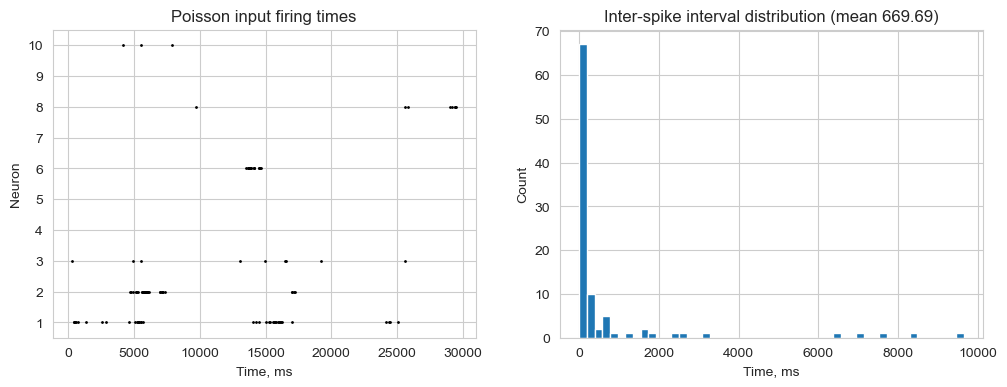

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))

for i, synapse in enumerate(neuron.synapses):
    time = synapse.stimuli
    axs[0].scatter(time, np.repeat(i + 1, repeats = len(time)), color = "black", s = 1)

axs[0].set_ylim(0.5, 10.5)
axs[0].set_ylabel("Neuron")
axs[0].set_yticks(np.arange(1, 11, 1))
axs[0].set_xlabel("Time, ms")
axs[0].set_title("Poisson input firing times")

freqs = []
for synapse in neuron.synapses:
    freqs.append(np.diff(synapse.stimuli)[1:])
freqs = np.concatenate(freqs)

axs[1].hist(freqs, bins = 50)
axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Count")
axs[1].set_title(f"Inter-spike interval distribution (mean {round(np.mean(freqs), 2)})")

plt.show()

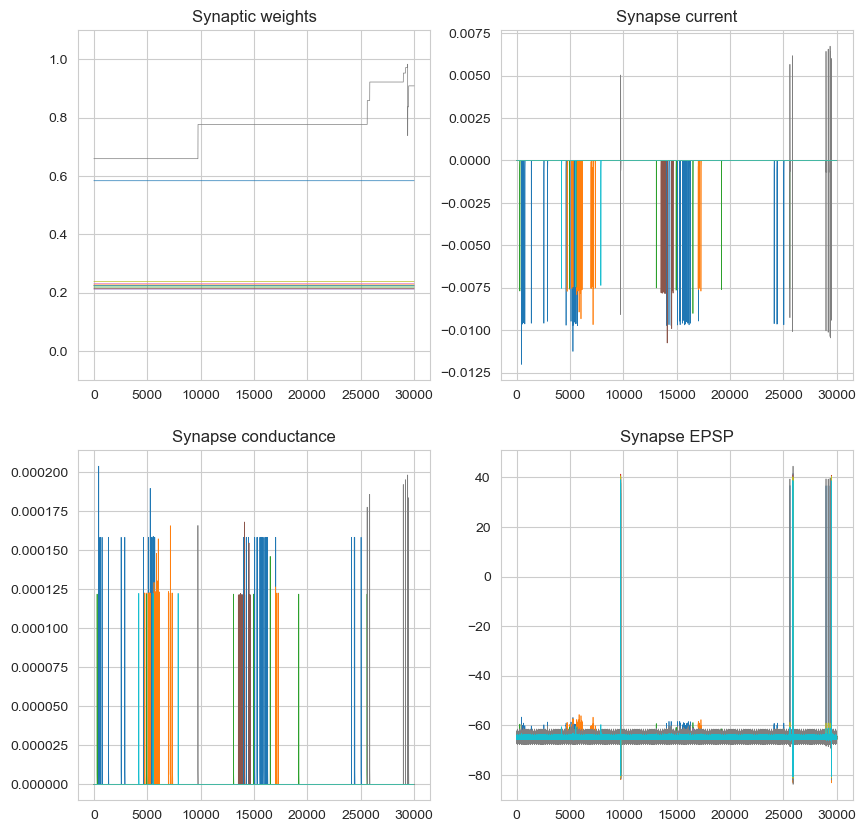

In [10]:
NeuronPlots.plot_all_synapses(neuron)

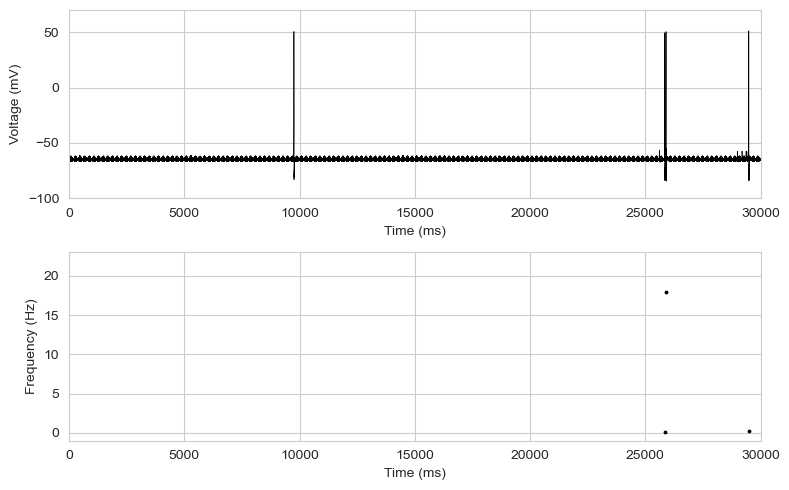

In [11]:
NeuronPlots.plot_spike_frequency(neuron)